## Nichtlineare Ausgleichsrechnung, Gauss-Newton und Levenberg-Marquardt
Ein nichtlineares Ausgleichsproblem ist ein Minimierungsproblem

$$
    |\vec{f}(\vec{p})|^2 \stackrel!= \textrm{min}
$$

für eine Funktion $\vec{f}:\mathbb{R}^n \to \mathbb{R}^{N}$. 

### Gauss-Newton Verfahren
Das **Gauss-Newton**-Verfahren ist sehr ähnlich, wie das Newtonverfahren für Gleichungssysteme:
  
* Wähle Startwerte $\vec{p}$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 \to \textrm{min}$
    * Setze $\vec{p} := \vec{p} + \vec{\delta}$

$J$ bezeichnet die Jacobimatrix von $\vec{f}$ an der Stelle $\vec{p}$.

Genau wie das Gaussverfahren, kann Gauss-Newton konvergieren oder auch nicht, ahängig von der konkreten Aufgabe und dem Startwert $\vec{p}$. Die Idee dahinter ist, dass

$$
    \vec{f}(\vec{p} + \vec{\delta}) \approx \vec{f}(\vec{p}) + J \vec{\delta}
$$

### Levenberg-Marquardt Verfahren
Das **Levenberg-Marquardt** Verfahren ist eine Erweiterung von Gauss-Newton mit dem Ziel, robustere Konvergenz zu erreichen.

* Wähle $0 < \beta_0 < \beta_1$. Diese Parameter bleiben während der Iteration konstant.
* Wähle Startwert $\vec{p}$ und $\mu > 0$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2 \to \textrm{min}$
    * Berechne $\rho$ (s. unten)
    * Falls $\rho < \beta_0$: setze $\mu := 2 \mu$ (und behalte $\vec{p}$, d.h. das berechnete $\delta$ wird verworfen)
    * Falls $\beta_0 \leq \rho < \beta_1$: setze $\vec{p} := \vec{p} + \vec{\delta}$ (und behalte $\mu$)
    * Falls $\beta_1 < \rho$: setze $\mu := \mu/2$ und $\vec{p} := \vec{p} + \vec{\delta}$   

Die Idee der Minimierung ist, die "Schrittweite" $|\delta|$ zu beschränken, indem der Zusatzterm $\mu^2 |\vec{\delta}|^2$ in die Minimierung einfliesst. Die Minimierung von 
$$
    |\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2
$$
ist jeweils ein *lineares* Ausgleichsproblem und kann erzielt werden, indem an die Jacobimatrix $J$ eine skalierte Einheitsmatrix $\mu \cdot E$ und an $\vec{f}(\vec{p})$ ein Nullvektor passender Länge angehängt wird.
 
Die Berechnung von $\rho$ ist

$$
    \rho = \frac{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p} + \vec{\delta})|^2}{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p}) + J\, \vec{\delta}|^2}
$$

Hier ist die Idee, die echte Verbesserung (Zähler) mit der effektiv erreichten Verbesserung (Nenner) zu vergleichen 

# Aufgabe 1: Gauss-Newton
Implementieren Sie das **Gauss-Newton Verfahren** und testen Sie es an dem Modell
$$
    y_i = u_0 \cdot e^{- a t} \cdot \sin (\omega t + \varphi)
$$

mit den Parametern $(u_0, a, \omega, \varphi)$ mit den Daten, die von dem folgenden Abschnitt erzeugt werden. Wälen Sie Startwerte, die nicht zu weit von den echten Werten (s. Code) abweichen. Experimentieren Sie ein wenig mit den Konvergenzeigenschaften von Gauss-Newton.

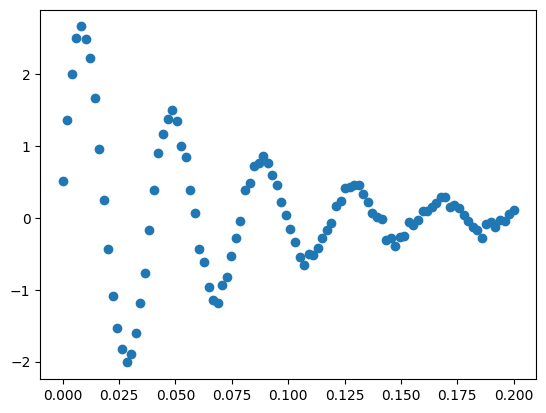

In [278]:
import numpy as np
import matplotlib.pyplot as plt

# Daten erzeugen mit den Parametern:
u0 = 3
a = 15
w = 25 * 2 * np.pi
phi = 10 * np.pi / 180

noiseAmp = 0.05 # Amplitude der Messfehler (kein Parameter des Modells)

N = 100
t = np.linspace(0, 5 * 2 * np.pi / w, 100)
y = u0 * np.exp(-a * t) * np.sin(w*t + phi) + noiseAmp * np.random.randn(N)

plt.scatter(t, y)

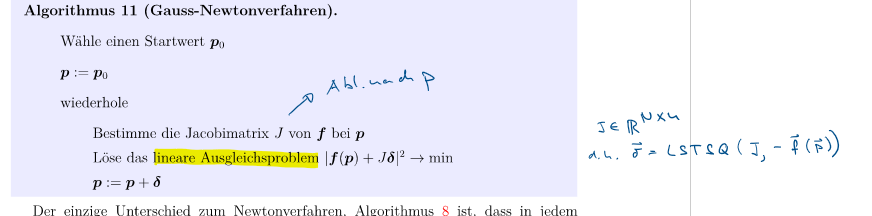

p     = [ 13.           2.         144.51326207   0.15707963] 	delta =  [11.76370412  1.17887217  9.34816471  0.17954091]
p     = [ 24.76370412   3.17887217 153.86142678   0.33662054] 	delta =  [-14.23234556  -0.34589958   4.55338978  -0.17892671]
p     = [1.05313586e+01 2.83297259e+00 1.58414817e+02 1.57693832e-01] 	delta =  [ 3.56531791e+00  1.28260896e-01 -6.24391873e-01  1.88060768e-03]
p     = [ 14.09667648   2.96123349 157.79042468   0.15957444] 	delta =  [ 0.83306451  0.05184835 -0.3852904   0.00596028]
p     = [ 14.92974099   3.01308184 157.40513428   0.16553472] 	delta =  [ 0.0128539   0.00055617 -0.03747421  0.00075615]
p     = [ 14.94259489   3.01363801 157.36766007   0.16629087] 	delta =  [ 1.46754612e-05 -9.69346811e-07 -5.01584497e-04  1.52454043e-05]
p     = [ 14.94260957   3.01363704 157.36715849   0.16630612] 	delta =  [ 2.69315907e-06  2.19238437e-07 -4.98656079e-06  1.49802821e-07]
p     = [ 14.94261226   3.01363726 157.3671535    0.16630627] 	delta =  [-2.73240904e-

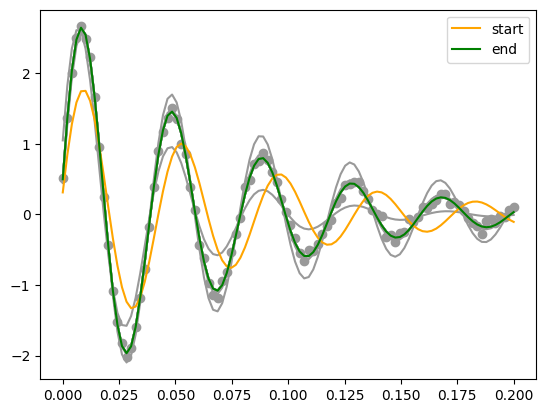

In [279]:
# Startwerte 
# ähnlich wie die paramter, einfach ein paar zahlen anderst damit man den unterschied gut sieht
u0 = 2
a = 13
w = 23 * 2 * np.pi
phi = 9 * np.pi / 180


p0 = np.array([a, u0, w, phi]) ## variablen (siehe aufgaben)
p = p0.copy() ##init


## funktion von oben:
f = lambda a, u0, w, phi: u0 * np.exp(-a * t) * np.sin(w*t + phi) 
## Jaccobi Matrix anhand f von oben:
J = lambda a, u0, w, phi: np.array([
    -t * u0 * np.exp(-a*t) * np.sin(w*t + phi),  # Ableitung nach a
    np.exp(-a*t) * np.sin(w*t + phi),            # Ableitung nach u0
    t * u0 * np.exp(-a*t) * np.cos(w*t + phi),   # Ableitung nach w
    u0 * np.exp(-a*t) * np.cos(w*t + phi)        # Ableitung nach phi
]).T


### kopiert aus beispiel, nichtlineare ausgleichsrechnung
from scipy.linalg import solve_triangular
## brauchen wir für gauss newton:
def lstsq(A, b):
    Q, R = np.linalg.qr(A)
    z = Q.T@b
    return solve_triangular(R, z)

for k in range(10):
    delta = lstsq(J(*p), y-f(*p)) # das Modell wäre f(p) - y = 0 -> Ausgleichsproblem: min J*d + (f(p) - y)
    print("p     =", p, "\tdelta = ", delta)
    p += delta
    plt.plot(t, f(*p), color = [.6,.6,.6])



plt.scatter(t, y, color = [.6,.6,.6])
plt.plot(t, f(*p0), color = "orange", label = "start") # Startwerte
plt.plot(t, f(*p), color = "green", label = "end")     # Nach Iteration

plt.legend()



# Aufgabe 2: Levenberg-Marquardt 
Implementieren Sie das **Levenberg-Marquardt Verfahren** und verwenden Sie dieses zur Bestimmung der Parameter

$$
    \vec{p} = (p_0, \ldots, p_6)
$$

des Modells

$$
    y = p_0 + p_1 \cdot \omega + p_2 \cdot \omega^2 + p_3 \cdot \omega^3 + p_4 \cdot \ell(p_5, p_6, {\color{gray} \omega})
$$

mit 

$$
    \ell(p_5, p_6, {\color{gray} \omega}) = \frac{1}{1 + 4 \cdot \left( \frac{\omega - p_5}{p_6} \right)^2}
$$

und testen Sie dieses an den Daten im file dataP7.txt.  

Das Modell ist dasselbe, wie in Praktikum 5 (lineare Ausgleichsrechnung), aber es sind zwei zusätzliche Parameter hinzugekommen, die in P5 als bekannt vorausgesetzt wurden. Das Modell ist immer noch linear in den Parametern $p_0, \ldots, p_4$. Sie werden feststellen, dass diese in der Jacobimatrix gar nicht vorkommen. Ein Teil der Jacobimatrix entspricht der Matrix des linearen Ausgleichsproblem aus P5.

* Verwenden Sie die QR-Zerlegung aus P5 zur Lösung der linearen Ausgleichsprobleme
* Skalieren Sie die $\omega$-Achse!
* Tipp zur besseren Lesbarkeit: erstellen sie Hilfsfunktionen für die Funktion $\ell$ die den Peak darstellt sowie für die benötigten partiellen Ableitungen davon.
* Bestimmen Sie Startwerte, indem Sie die Modellfunktion plotten und mit den Daten vergleichen. Versuchen Sie nicht, die Startwerte allzu genau zu machen - schliesslich wollen Sie sehen, wie gut Levenberg-Marquardt mit mittelmässigen Startwerten zurecht kommt!

**Bemerkung**: Die Daten sind nicht exakt identisch mit den Daten aus P5

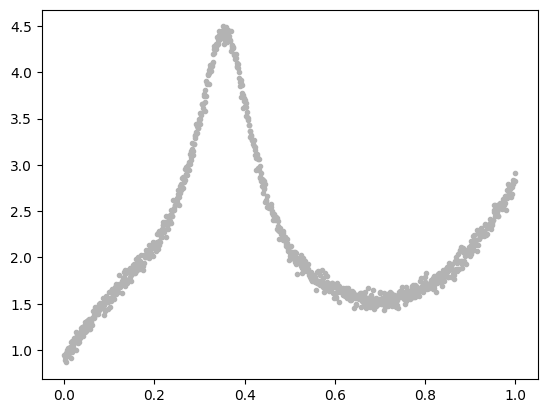

In [280]:
import numpy as np
import matplotlib.pyplot as plt 

data = np.genfromtxt("NUM1_Praktikum_W8_data.txt") ## namen angepasst
w, y = data.T

# Skalierung w, auf werte 0-1, da sie von 80000-81000 sind runternehmen
def scale(w):
    ws  = (w-80000) /1000
    return ws

w = scale(w)

plt.plot(w, y, '.', color = [.7,.7,.7]);

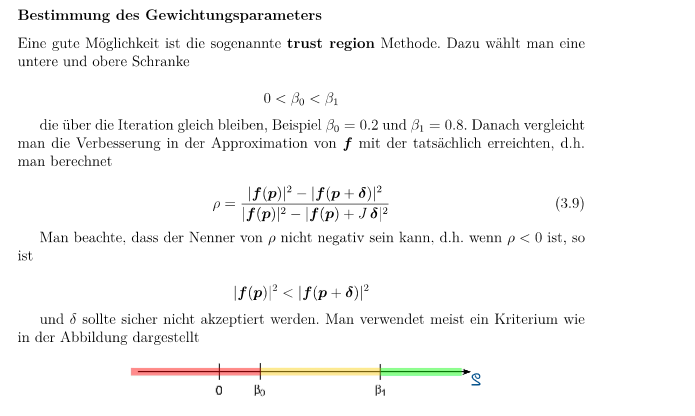

In [281]:
###---------------------------RHO FUNKTION-----------------------------------------
def rho(f, J, p, delta):
    fp2 = np.linalg.norm(f(*p))**2
    fpdelta2 = np.linalg.norm(f(*p + delta))**2
    fpJ2 = np.linalg.norm(f(*p) + J(*p) @ delta)**2

    return (fp2 - fpdelta2) / (1e-12 + fp2 - fpJ2) 

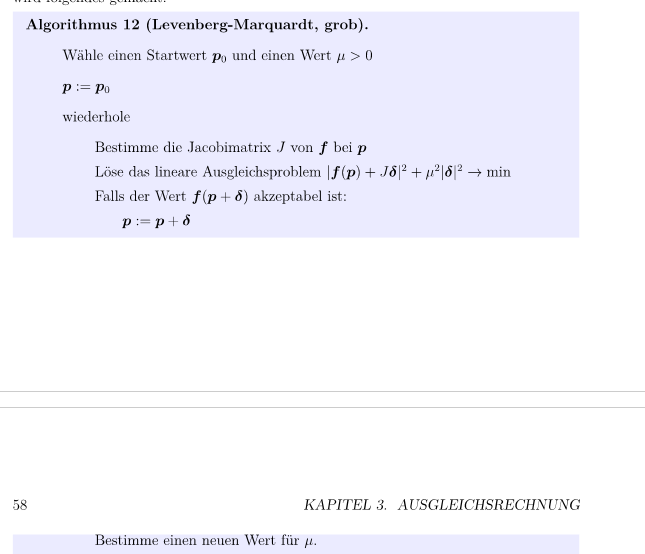

0 : f(p) =  67.76238 	 mu =  0.1 	 |delta| =  50.82748321355648 	 rho =  0.4031122091613759
1 : f(p) =  37.00633 	 mu =  0.1 	 |delta| =  16.967124817157618 	 rho =  1.9134263231824258
2 : f(p) =  147.31053 	 mu =  0.05 	 |delta| =  25.625879188740733 	 rho =  1.0041493075519514
3 : f(p) =  15.06544 	 mu =  0.025 	 |delta| =  0.50713279469592 	 rho =  1.0001150937543584
4 : f(p) =  15.06435 	 mu =  0.0125 	 |delta| =  0.06386807402331737 	 rho =  0.12348669925296757
5 : f(p) =  15.06435 	 mu =  0.025 	 |delta| =  0.01627036795821018 	 rho =  0.9460651545823168
6 : f(p) =  15.06435 	 mu =  0.0125 	 |delta| =  0.0635918567171456 	 rho =  -13.419399909267081
7 : f(p) =  15.06435 	 mu =  0.025 	 |delta| =  0.015897977433940037 	 rho =  0.0971794176464446
8 : f(p) =  15.06435 	 mu =  0.05 	 |delta| =  0.0039745417487736644 	 rho =  0.9434584939337411
9 : f(p) =  15.06435 	 mu =  0.025 	 |delta| =  0.01588598885442907 	 rho =  -14.203256476409202
10 : f(p) =  15.06435 	 mu =  0.05 	 |delta| 

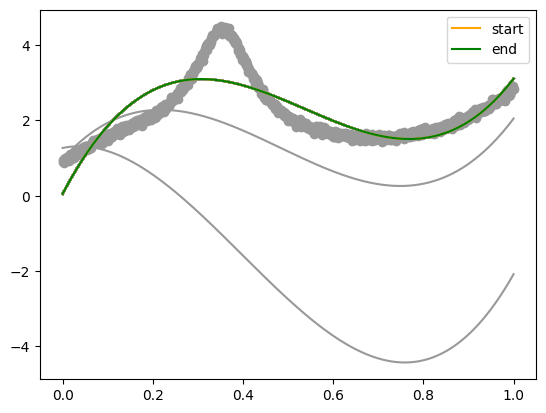

In [282]:
## startwerte definieren

p0 = 0.1
p1 = 0.1
p2 = 0.1
p3 = 0.1
p4 = 0.1
p5 = 0.1
p6 = 0.1

#startwerte
pStart = np.array([p0, p1, p2, p3, p4, p5, p6]) # Startwerte


# Hilfsfunktion L, nachher aufgerufen in F, definiert in aufgabenstellung
l = lambda p5, p6, w: 1 / (1 + 4 * ((w - p5) / p6)**2)

#f, definiert in aufgabenstellung
f = lambda p0, p1, p2, p3, p4, p5, p6: (
    p0 + p1*w + p2*w**2 + p3*w**3 + p4 * l(p5, p6, w)
)

# Jacobi-Matrix von f
J = lambda p0, p1, p2, p3, p4, p5, p6: np.array([
    np.ones_like(w),          # Ableitung nach p0 
    w,                        # Ableitung nach p1 
    w**2,                     # Ableitung nach p2 
    w**3,                     # Ableitung nach p3 
    l(p5, p6, w),             # Ableitung nach p4     
    p4 * (8 * (w - p5) / p6**2) * l(p5, p6, w)**2, # Ableitung nach p5 (Zentrum/Position des Peaks) 
    p4 * (8 * (w - p5)**2 / p6**3) * l(p5, p6, w)**2 # Ableitung nach p6 (Breite des Peaks)
]).T


## übergebe P der Jaccobi:
Je = lambda p0, p1, p2, p3, p4, p5, p6: J(*p)



## init
pLM = pStart.copy()

##FUNKTION LM, aus beipsiel Lineare ausgleichsrechnung!!!
def LM(f, J, p, beta0 = 0.2, beta1 = 0.8, mu = 0.1, maxit = 100):

    n = len(p)
    delta = 1
    it = 0

    while np.linalg.norm(delta) > 1e-8 and it < maxit:
        
        Jext = np.concatenate( (J(*p), mu * np.eye(n)) )
        fext = np.concatenate ((y - f(*p), np.zeros(n)) ) # das Modell wäre f(p) - y = 0
        
        delta = lstsq(Jext, fext) # lineares Ausgleichsproblem lösen
        r = rho(f, J, p, delta)
    
        print(it, 
          ": f(p) = ", np.round(np.linalg.norm(y - f(*p)), 5), 
          "\t mu = ", mu, 
          "\t |delta| = ", np.linalg.norm(delta),
          "\t rho = ", r)

    
        if r < beta0:
            mu *= 2
        elif r < beta1:
            p += delta
        else:
            p += delta
            mu /= 2
    
        it += 1

        plt.plot(w, f(*p), color = [.6,.6,.6])

    return p

##- LOEWENBERG LANDQUARD AUFRUFEN
pLM = LM(f, J, pStart, maxit = 500)



##-------------------PLOT---------------------------------------------
plt.scatter(w, y, color = [.6,.6,.6])
plt.plot(w, f(*pStart), color = "orange", label = "start") # mit Startwerten
plt.plot(w, f(*pLM), color = "green", label = "end")     # nach levenberg-Marquardt

plt.legend()

print("gefundene Parameter: ", pLM)